In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# set dataset directory
dataset_dir = "/home/kevin/Desktop/gut_microbiome/dataset/hmc"
dataset_fp = f"{dataset_dir}/taxonomic_table.csv"

# load data into pandas
df = pd.read_csv(dataset_fp)

In [3]:
df.shape

(168464, 4682)

In [4]:
df.columns

Index(['Unnamed: 0', 'sample',
       'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter',
       'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella',
       'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia',
       'Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia',
       'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella',
       'Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.NA',
       'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Lactiplantibacillus',
       'Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus',
       ...
       'Bacteria.Planctomycetota.Phycisphaerae.Phycisphaerales.Phycisphaeraceae.JL-ETNP-F27',
       'Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Microcystaceae.Crocosphaera',
       'Bacteria.Pseudomonado

/tmp/ipykernel_7705/2030975435.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i for i in range(4680)], y=bacteria_presence.values, palette='viridis')


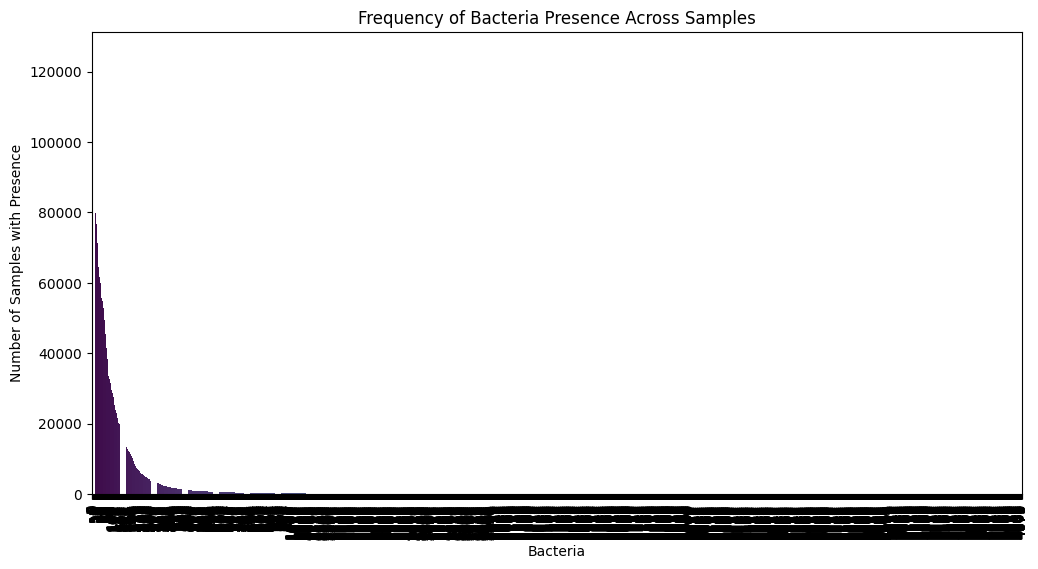

In [17]:
# Count the number of nonzero occurrences per bacteria (column)
bacteria_presence = (df != 0).sum()

# Sort from most frequent to least frequent
bacteria_presence = bacteria_presence.sort_values(ascending=False)
# drop first two cuz they are labels
bacteria_presence = bacteria_presence[2:]
# Plot the data
plt.figure(figsize=(12, 6))
sns.barplot(x=[i for i in range(4680)], y=bacteria_presence.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Bacteria')
plt.ylabel('Number of Samples with Presence')
plt.title('Frequency of Bacteria Presence Across Samples')
plt.show()


Number of bacteria species covering 97% of data: 666


/tmp/ipykernel_7705/3077904894.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=smaller_table.index, y=smaller_table.values, palette='viridis')


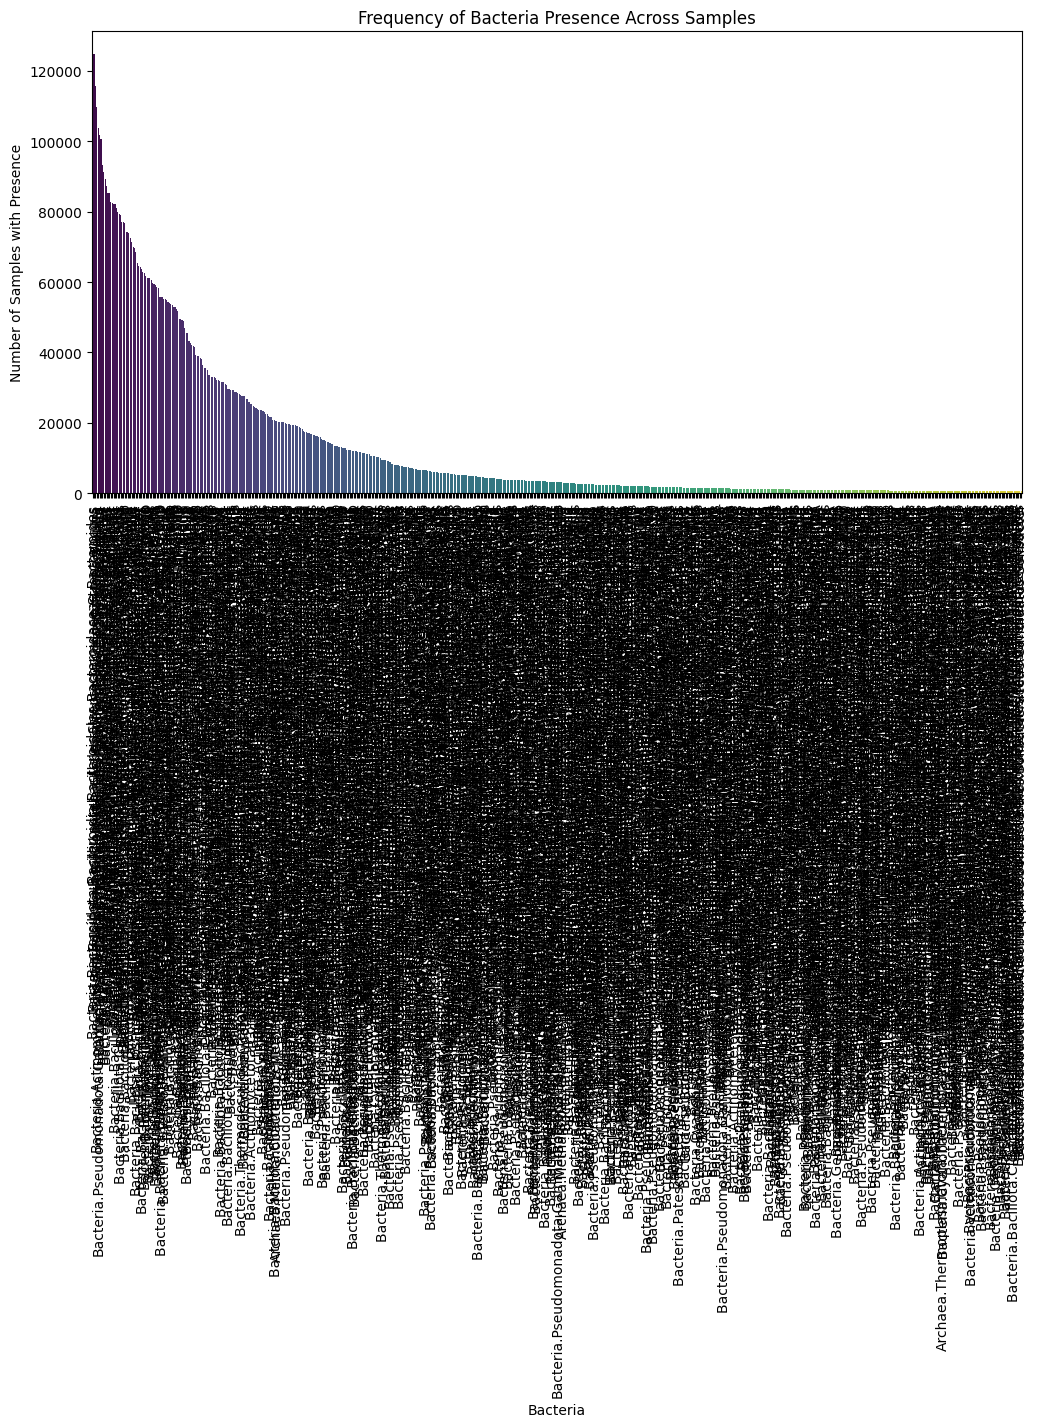

In [18]:
# Compute cumulative sum and find the number of species covering 97% of occurrences
cumulative_sum = bacteria_presence.cumsum()
total_sum = bacteria_presence.sum()
top_97_species = (cumulative_sum / total_sum <= 0.97).sum()
print(f'Number of bacteria species covering 97% of data: {top_97_species}')

# Plot the data
smaller_table = bacteria_presence[:top_97_species]
plt.figure(figsize=(12, 6))
sns.barplot(x=smaller_table.index, y=smaller_table.values, palette='viridis')
plt.xticks(rotation=90)
plt.xlabel('Bacteria')
plt.ylabel('Number of Samples with Presence')
plt.title('Frequency of Bacteria Presence Across Samples')
plt.show()

In [19]:
top_512_percentage = cumulative_sum.iloc[511] / total_sum * 100
print(f'Percentage of total data in the most frequent 512 species: {top_512_percentage:.2f}%')

Percentage of total data in the most frequent 512 species: 95.71%


In [21]:
bacteria_presence.index

Index(['Bacteria.Bacteroidota.Bacteroidia.Bacteroidales.Bacteroidaceae.Bacteroides',
       'Bacteria.Bacillota.Bacilli.Lactobacillales.Streptococcaceae.Streptococcus',
       'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Blautia',
       'Bacteria.Actinomycetota.Actinobacteria.Bifidobacteriales.Bifidobacteriaceae.Bifidobacterium',
       'Bacteria.Pseudomonadota.Gammaproteobacteria.Enterobacterales.Enterobacteriaceae.Escherichia-Shigella',
       'Bacteria.Bacillota.Clostridia.Oscillospirales.Ruminococcaceae.Faecalibacterium',
       'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.NA',
       'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Anaerostipes',
       'Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Mediterraneibacter',
       'Bacteria.Bacteroidota.Bacteroidia.Bacteroidales.Tannerellaceae.Parabacteroides',
       ...
       'Bacteria.Bacillota.Dethiobacteria.Dethiobacterales.Dethiobacteraceae.NA',
       'Bacteria.Pse

In [24]:
df

,Unnamed: 0,sample,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.NA,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Lactiplantibacillus,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus,...,Bacteria.Planctomycetota.Phycisphaerae.Phycisphaerales.Phycisphaeraceae.JL-ETNP-F27,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Microcystaceae.Crocosphaera,Bacteria.Pseudomonadota.Alphaproteobacteria.Rickettsiales.Rickettsiaceae.Candidatus Gigarickettsia,Bacteria.Bacillota.Bacilli.Bacillales.Bacillaceae.Streptohalobacillus,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Cyanobacteriaceae.Cyanobacterium PCC-10605,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Flavirhabdus,Bacteria.Pseudomonadota.Alphaproteobacteria.Rhodobacterales.Paracoccaceae.Octadecabacter,Bacteria.Pseudomonadota.Alphaproteobacteria.Acetobacterales.Acetobacteraceae.Swingsia,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Aurantiacicella,Archaea.Halobacteriota.Halobacteria.Halobacterales.Halobacteriaceae.Halocalculus
0,1,PRJDB10485_DRR243823,179,435,481,653,471,6,109,495,...,0,0,0,0,0,0,0,0,0,0
1,2,PRJDB10485_DRR243824,0,667,435,140,1798,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,PRJDB10485_DRR243825,0,2025,0,0,3651,0,0,34,...,0,0,0,0,0,0,0,0,0,0
3,4,PRJDB10485_DRR243826,0,1760,0,0,669,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,PRJDB10485_DRR243827,843,6937,366,4222,2166,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168459,168460,PRJNA764337_SRR15959697,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
168460,168461,PRJNA764337_SRR15959698,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
168461,168462,PRJNA764337_SRR15959699,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
168462,168463,PRJNA764337_SRR15959700,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
df_small = df[bacteria_presence[:512].index]

In [26]:
total_cells = df_small.size
nonzero_cells = (df_small != 0).sum().sum()
table_populated_percentage = (nonzero_cells / total_cells) * 100
print(f'Percentage of the entire table populated with data: {table_populated_percentage:.2f}%')

Percentage of the entire table populated with data: 10.27%


In [28]:
(df_small != 0).sum()

Bacteria.Bacteroidota.Bacteroidia.Bacteroidales.Bacteroidaceae.Bacteroides                              124933
Bacteria.Bacillota.Bacilli.Lactobacillales.Streptococcaceae.Streptococcus                               124614
Bacteria.Bacillota.Clostridia.Lachnospirales.Lachnospiraceae.Blautia                                    115633
Bacteria.Actinomycetota.Actinobacteria.Bifidobacteriales.Bifidobacteriaceae.Bifidobacterium             109718
Bacteria.Pseudomonadota.Gammaproteobacteria.Enterobacterales.Enterobacteriaceae.Escherichia-Shigella    103598
                                                                                                         ...  
Bacteria.Bacillota.Bacilli.Bacillales.Bacillaceae.Niallia                                                 1030
Bacteria.Actinomycetota.Actinobacteria.Bifidobacteriales.Bifidobacteriaceae.Parascardovia                 1019
Bacteria.Nitrospirota.Nitrospiria.Nitrospirales.Nitrospiraceae.Nitrospira                                 1015
B

Number of populated columns per sample:
0         57
1         62
2         50
3         56
4         45
          ..
168459     8
168460     7
168461     8
168462     7
168463     8
Length: 168464, dtype: int64


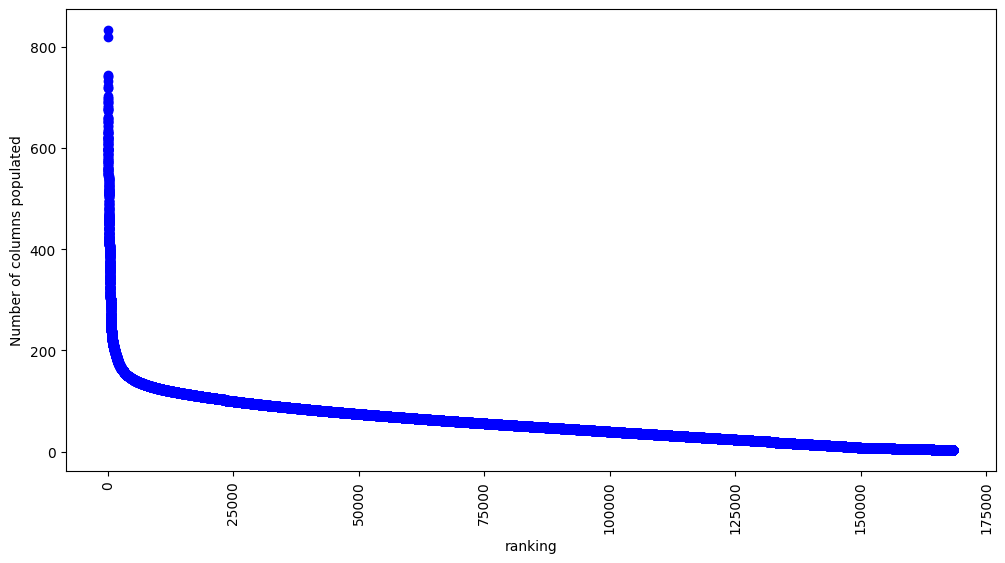

In [39]:
columns_populated_per_sample = (df != 0).sum(axis=1)
print("Number of populated columns per sample:")
print(columns_populated_per_sample)
# Sort from most populated to least populated
columns_populated_per_sample = columns_populated_per_sample.sort_values(ascending=False)
# Plot the data
plt.figure(figsize=(12, 6))
plt.scatter(x=np.array([i for i in range(columns_populated_per_sample.shape[0])]), y=columns_populated_per_sample.values, color='blue')
plt.xticks(rotation=90)
plt.xlabel('ranking')
plt.ylabel('Number of columns populated')
plt.show()

In [33]:
columns_populated_per_sample

121263    833
121886    820
121882    745
121164    743
121835    741
         ... 
121984      3
121995      3
35971       3
36044       3
36038       3
Length: 168464, dtype: int64